# Предобработка и графики из 1го контеста

In [161]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('train.csv')

# Удаление дубликатов и полностью пустых строк
df = df.drop_duplicates()
df = df.dropna(how='all')

# Фильтрация некорректных значений RiskScore
df = df[(df['RiskScore'] >= 0) & (df['RiskScore'] <= 100)]

# Удаление строк с пропусками
df = df.dropna()

# Преобразование ApplicationDate в числовой формат (таймштамп)
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
df['ApplicationDate'] = df['ApplicationDate'].astype(int) / 10**9

# Преобразование категориальных переменных в бинарные с помощью One-Hot Encoding
df = pd.get_dummies(data=df, columns=df.select_dtypes(include=object).columns, drop_first=True)

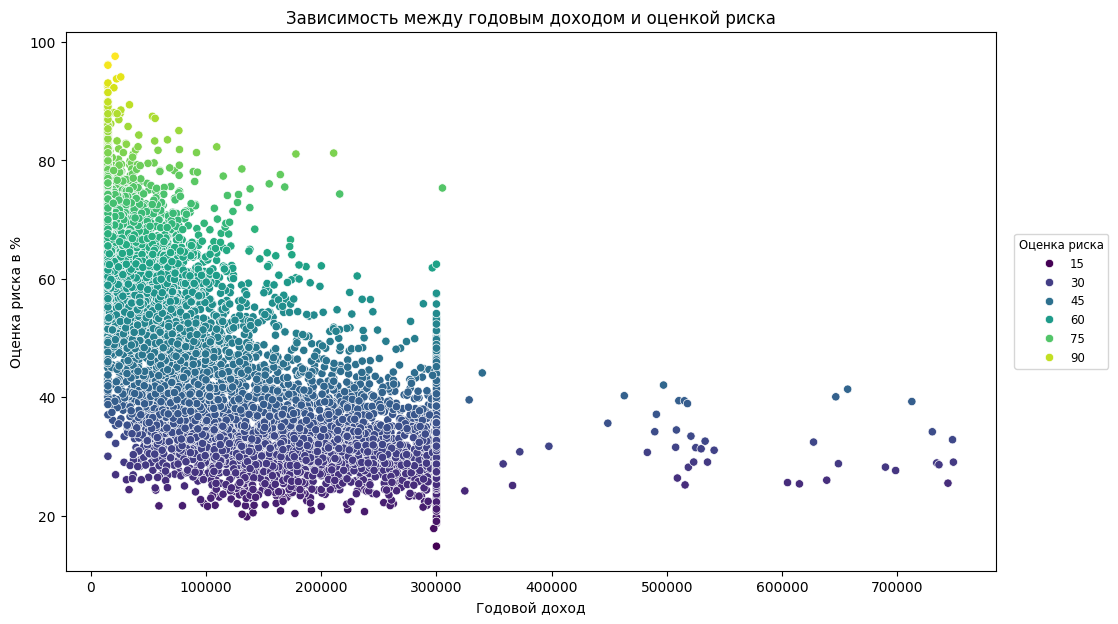

In [99]:
plt.figure(figsize=(12, 7))
sns.scatterplot(df, x='AnnualIncome', y='RiskScore', hue='RiskScore', palette='viridis')
plt.title('Зависимость между годовым доходом и оценкой риска')
plt.xlabel('Годовой доход')
plt.ylabel('Оценка риска в %')
plt.legend(title='Оценка риска', loc='center left', fontsize='small', title_fontsize='small', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.show()

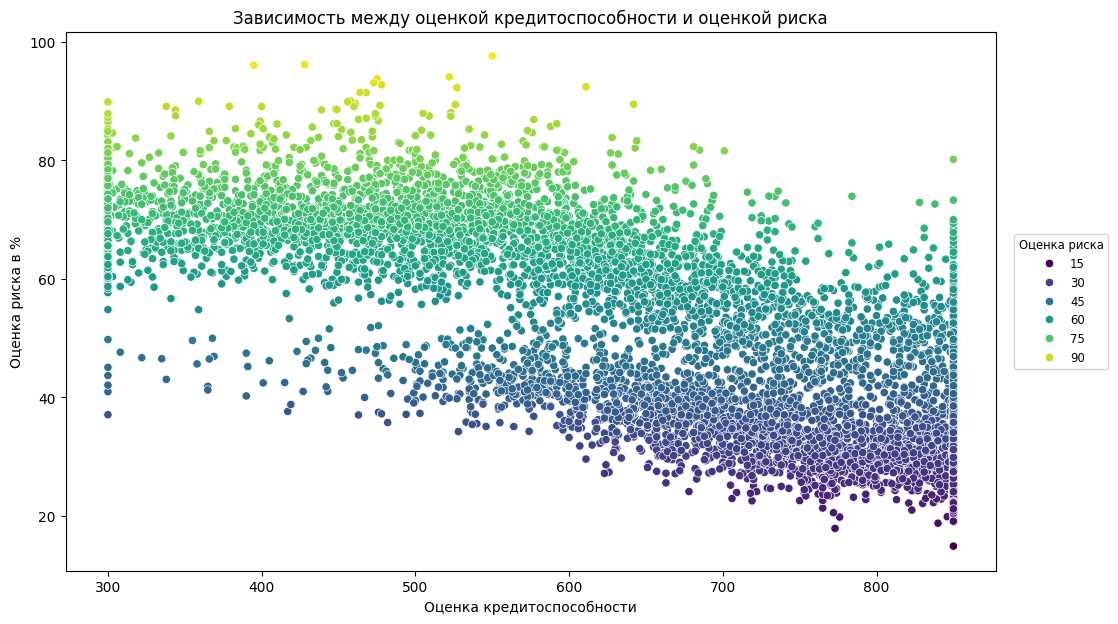

In [100]:
plt.figure(figsize=(12, 7))
sns.scatterplot(df, x='CreditScore', y='RiskScore', hue='RiskScore', palette='viridis')
plt.title('Зависимость между оценкой кредитоспособности и оценкой риска')
plt.xlabel('Оценка кредитоспособности')
plt.ylabel('Оценка риска в %')
plt.legend(title='Оценка риска', loc='center left', fontsize='small', title_fontsize='small', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.show()

# Лабораторная работа №2


Теперь целевая переменная `LoanApproved`.

Ради интереса посмотрим на зависимость от той же части признаков, но с другой целевой переменной.


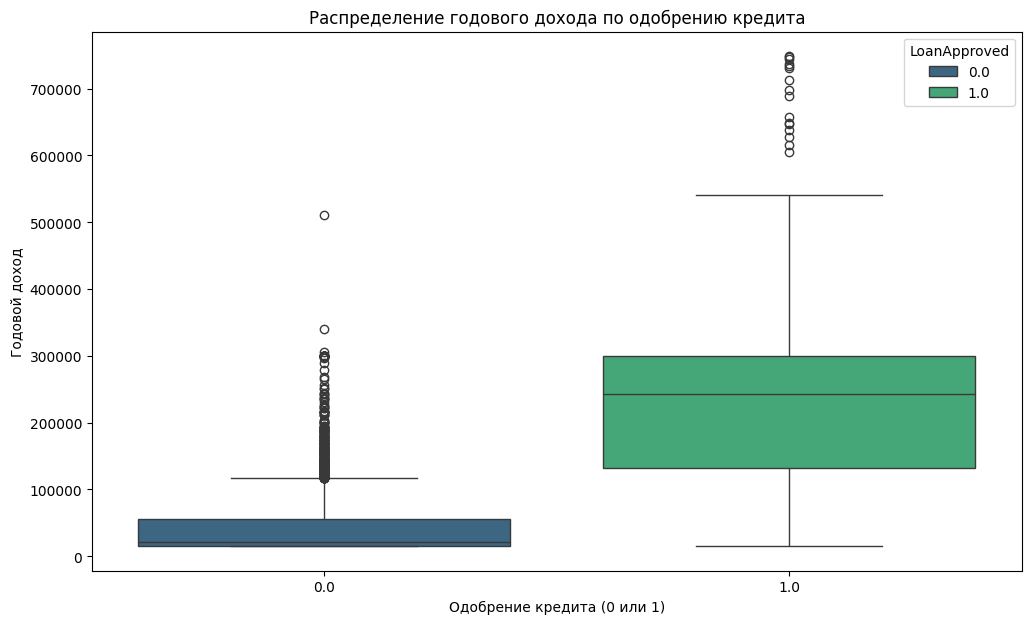

In [101]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='LoanApproved', y='AnnualIncome', hue='LoanApproved', palette='viridis')
plt.title('Распределение годового дохода по одобрению кредита')
plt.xlabel('Одобрение кредита (0 или 1)')
plt.ylabel('Годовой доход')
plt.show()

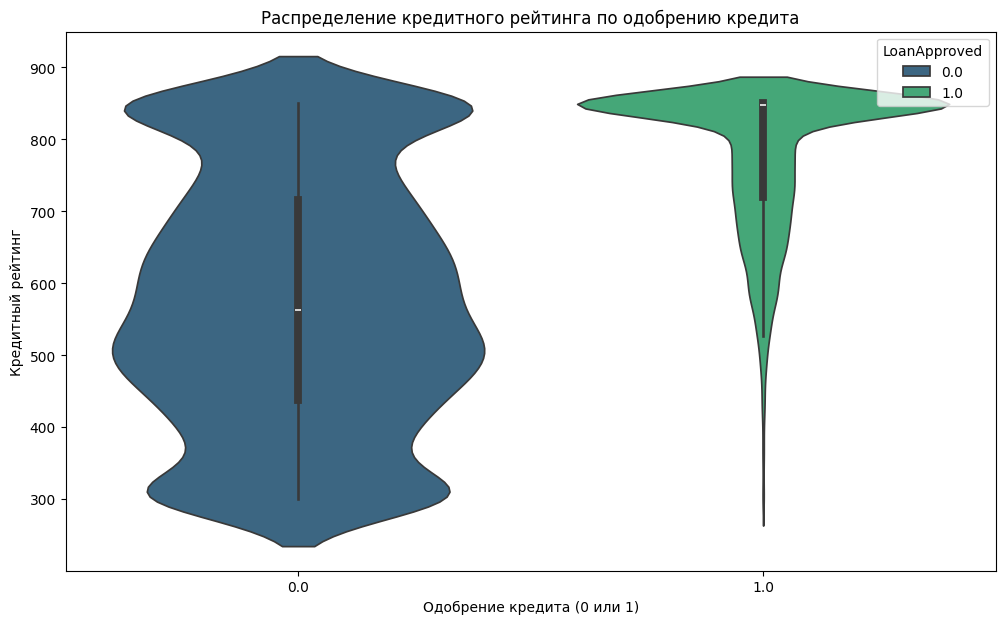

In [102]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=df, x='LoanApproved', y='CreditScore', hue='LoanApproved', palette='viridis')
plt.title('Распределение кредитного рейтинга по одобрению кредита')
plt.xlabel('Одобрение кредита (0 или 1)')
plt.ylabel('Кредитный рейтинг')
plt.show()

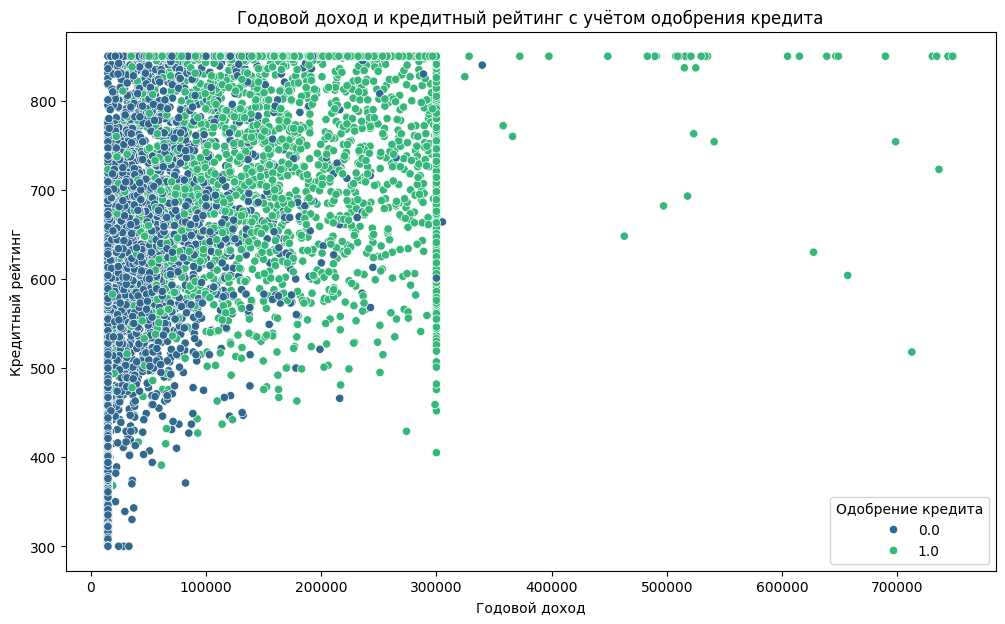

In [103]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='AnnualIncome', y='CreditScore', hue='LoanApproved', palette='viridis')
plt.title('Годовой доход и кредитный рейтинг с учётом одобрения кредита')
plt.xlabel('Годовой доход')
plt.ylabel('Кредитный рейтинг')
plt.legend(title='Одобрение кредита')
plt.show()

Последний график интересный.

Можно увидеть, насколько сильно влияет годовой доход на одобрение кредита в отличие от кредитного рейтинга.

  # Решение задачи бинарной классиификации различными способами

Убедимся, что целевая переменная имеет значения 0 и 1:

In [162]:
if df['LoanApproved'].dtype == 'object':
    df['LoanApproved'] = df['LoanApproved'].map({'Yes': 1, 'No': 0})

Реализация класса с методами fit и predict для логистической регрессии и линейного классификатора:

In [163]:
class MyLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)

        for _ in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return np.array([1 if i > 0.5 else 0 for i in y_predicted])

Разделение на тренировочную и тестовую выборки:

In [164]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Для методов, чувствительных к масштабу данных (логистическая регрессия, SVM), полезно масштабировать числовые признаки:

In [165]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_np = y_train.to_numpy()

Решаем задачу бинарной классификации с помощью нашей и других готовых реализаций, для каждого решения считаем метрики и визуализируем confusion matrix.

Training MyLogisticRegression...


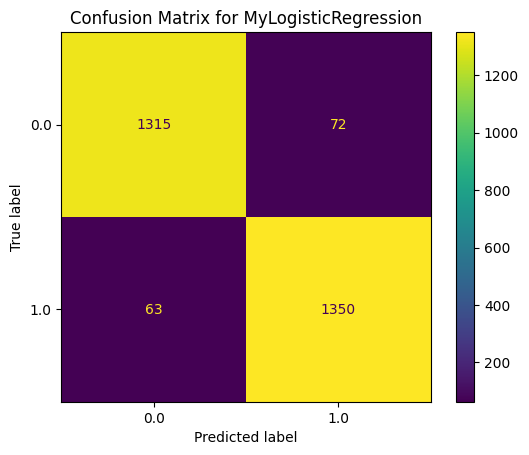

Training LogisticRegression...


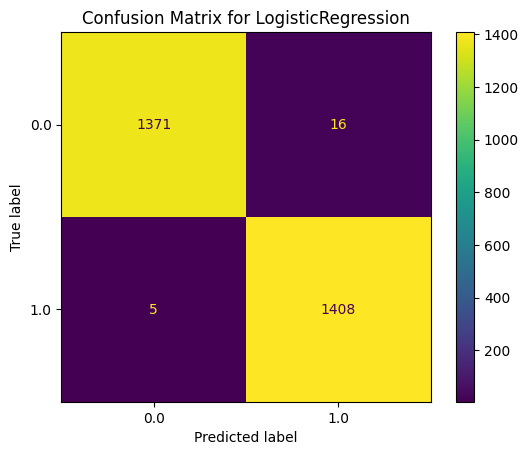

Training SVM...


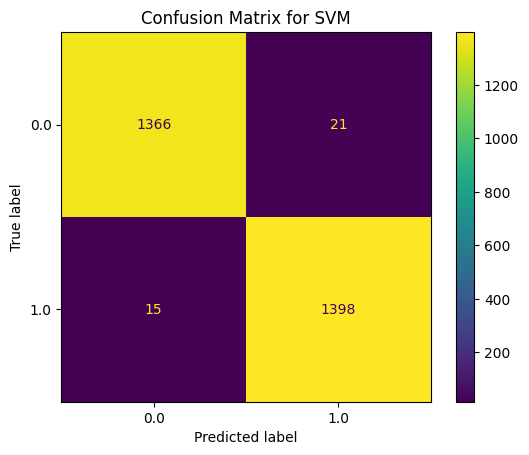

Training DecisionTree...


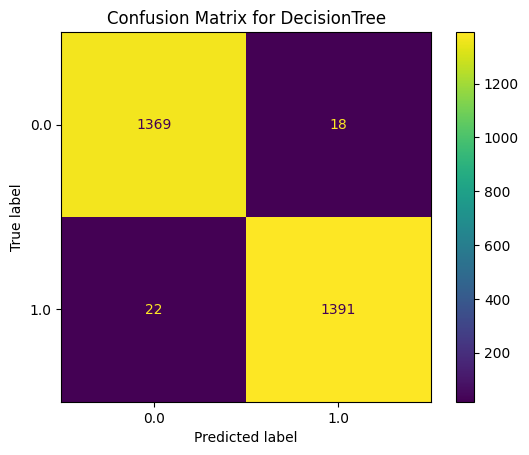

Training RandomForest...


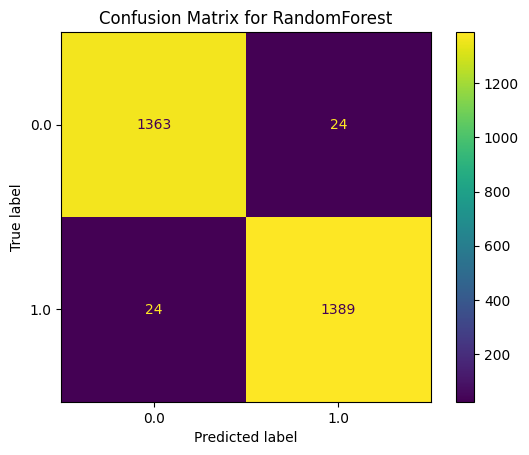

Training GradientBoosting...


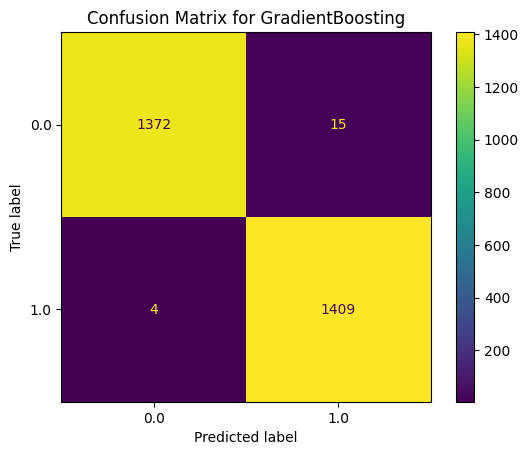

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3376, number of negative: 3156
[LightGBM] [Info] Total Bins 5103
[LightGBM] [Info] Number of data points in the train set: 6532, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516840 -> initscore=0.067386
[LightGBM] [Info] Start training from score 0.067386


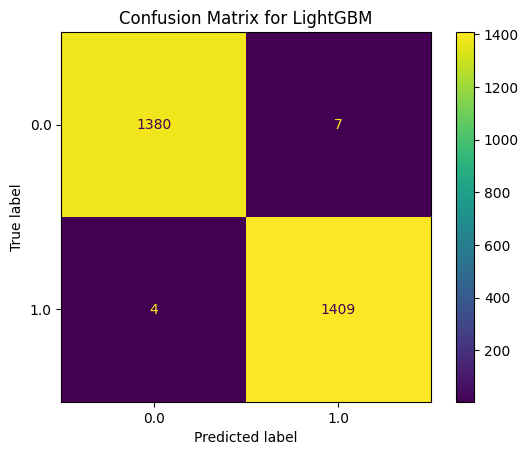

Training XGBoost...


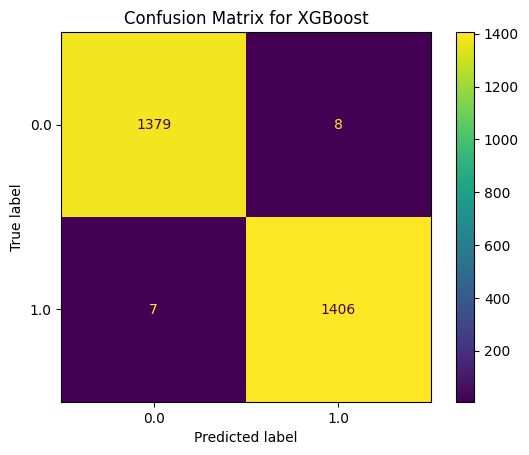

Training CatBoost...


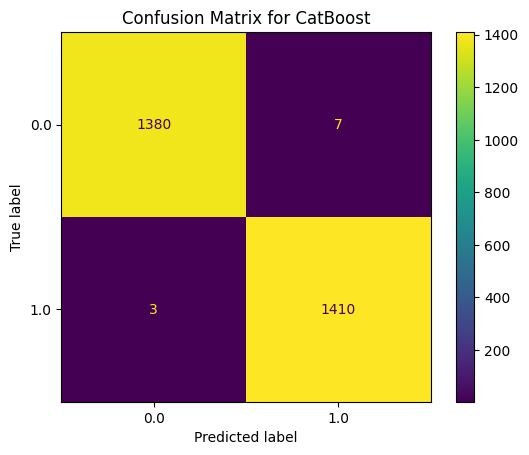

Metrics for MyLogisticRegression:
Metrics for Class 0.0:
  Precision: 0.95
  Recall: 0.95
  F1-Score: 0.95
Metrics for Class 1.0:
  Precision: 0.95
  Recall: 0.96
  F1-Score: 0.95
Accuracy: 0.95
--------------------------------------------------
Metrics for LogisticRegression:
Metrics for Class 0.0:
  Precision: 1.00
  Recall: 0.99
  F1-Score: 0.99
Metrics for Class 1.0:
  Precision: 0.99
  Recall: 1.00
  F1-Score: 0.99
Accuracy: 0.99
--------------------------------------------------
Metrics for SVM:
Metrics for Class 0.0:
  Precision: 0.99
  Recall: 0.98
  F1-Score: 0.99
Metrics for Class 1.0:
  Precision: 0.99
  Recall: 0.99
  F1-Score: 0.99
Accuracy: 0.99
--------------------------------------------------
Metrics for DecisionTree:
Metrics for Class 0.0:
  Precision: 0.98
  Recall: 0.99
  F1-Score: 0.99
Metrics for Class 1.0:
  Precision: 0.99
  Recall: 0.98
  F1-Score: 0.99
Accuracy: 0.99
--------------------------------------------------
Metrics for RandomForest:
Metrics for Class

In [166]:
import warnings
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

models = {
    "MyLogisticRegression": MyLogisticRegression(),
    "LogisticRegression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "LightGBM": LGBMClassifier(force_row_wise=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=0)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")

    if name in ["MyLogisticRegression", "LogisticRegression", "SVM"]:
        model.fit(X_train_scaled, y_train_np if name == "MyLogisticRegression" else y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Расчет метрик
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = report

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    disp.plot(cmap='viridis')
    plt.title(f"Confusion Matrix for {name}")
    plt.show()

# Вывод метрик для всех моделей
for name, metrics in results.items():
    print(f"Metrics for {name}:")
    metrics = {str(k): v for k, v in metrics.items()}

    for class_label in ['0.0', '1.0']:
        if class_label in metrics:
            print(f"Metrics for Class {class_label}:")
            print(f"  Precision: {metrics[class_label]['precision']:.2f}")
            print(f"  Recall: {metrics[class_label]['recall']:.2f}")
            print(f"  F1-Score: {metrics[class_label]['f1-score']:.2f}")
        else:
            print(f"  Metrics for Class {class_label} are not available.")

    # Общая точность (Accuracy)
    print(f"Accuracy: {metrics['accuracy']:.2f}")
    print("-" * 50)

# Вывод


Все модели показали высокие значения метрик, LightGBM и CatBoost показали наилучшие результаты, достигнув 100% точности (accuracy) и максимальных значений метрик для класса 1, что объясняется высокой мощностью и адаптивностью градиентного бустинга. Самописная MyLogisticRegression работает корректно, но её результаты уступают готовым библиотечным решениям. Метрики для обоих классов (0 и 1) сбалансированы, что говорит о том, что модели хорошо справляются с задачей даже при небольшом дисбалансе классов (около 52% для класса 1). Наиболее информативной метрикой в этой задаче оказался F1-Score для класса 1, так как он наиболее точно отражает баланс между ложноположительными и ложноотрицательными предсказаниями. Это особенно важно для задач, где оба аспекта критичны, например, в кредитном скоринге.